# Binary Classification
using imdb dataset

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras import datasets, layers, Sequential

## 1- Data Preparation

### Load and Inspect the Dataset

In [5]:
(train_data, train_labels), (test_data, test_labels) = datasets.imdb.load_data(num_words=10000)

In [8]:
print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(25000,)
(25000,)
(25000,)
(25000,)


In [25]:
print(len(train_data[0]))
print(train_labels[0])

print(len(train_data[1]))
print(train_labels[1])

218
1
189
0


In [28]:
np.unique(train_labels)

array([0, 1])

In [20]:
word_index = datasets.imdb.get_word_index()
len(word_index)

88584

In [36]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])
print(decoded_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

11
2494


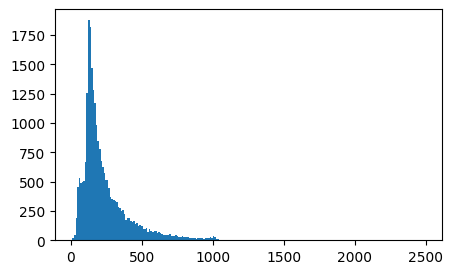

In [41]:
lengths = [len(i) for i in train_data]
print(np.min(lengths))
print(np.max(lengths))

plt.figure(figsize=(5,3))
plt.hist(lengths, bins='auto')
plt.show()

### Pre-processing

In [34]:
def multi_hot_encode(sequences, num_words):
    results = np.zeros((len(sequences), num_words))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.
    return results
    
x_train = multi_hot_encode(train_data, num_words=10000)
x_test = multi_hot_encode(test_data, num_words=10000)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

y_train = train_labels.astype('float32')
y_test = test_labels.astype('float32')

print(x_train.shape)
print(x_test.shape)

(25000, 10000)
(25000, 10000)


In [33]:
x_train[0]

dtype('float64')

### Prepare Validation Set

In [42]:
x_val = x_train[:10_000]
partial_x_train = x_train[10_000:]

y_val = y_train[:10_000]
partial_y_train = y_train[10_000:]

## 2- Model Design

In [45]:
x_train[0].shape

(10000,)

In [46]:
model = Sequential([
    layers.Input(shape=x_train[0].shape),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │         160,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## 3- Training

In [49]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

In [51]:
history = model.fit(partial_x_train, partial_y_train,
                    epochs=20, batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7660 - loss: 0.5591 - val_accuracy: 0.8580 - val_loss: 0.4093
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8982 - loss: 0.3047 - val_accuracy: 0.8870 - val_loss: 0.2961
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9315 - loss: 0.2025 - val_accuracy: 0.8886 - val_loss: 0.2777
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9554 - loss: 0.1481 - val_accuracy: 0.8867 - val_loss: 0.2826
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9675 - loss: 0.1132 - val_accuracy: 0.8843 - val_loss: 0.3076
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9777 - loss: 0.0864 - val_accuracy: 0.8811 - val_loss: 0.3227
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9852 - loss: 0.0658 - val_accuracy: 0.8817 - val_loss: 0.3545
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9914 - loss: 0.0507 - val_accuracy: 0.8772 - val_

## 4- Evaluation

In [54]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.7329
Test Accuracy: 0.8533


In [56]:
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.766000,0.559102,0.8580,0.409321
1,0.898200,0.304715,0.8870,0.296146
2,0.931533,0.202523,0.8886,0.277705
3,0.955400,0.148147,0.8867,0.282605
4,0.967533,0.113246,0.8843,0.307642


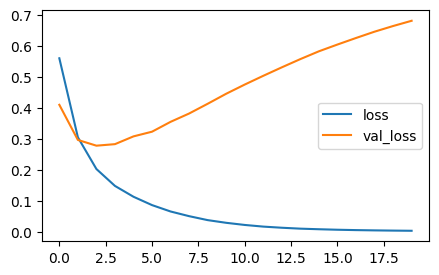

In [59]:
history_df[['loss', 'val_loss']].plot(figsize=(5,3))
plt.show()

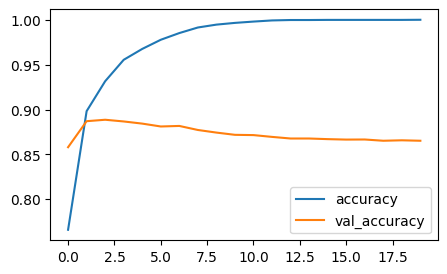

In [60]:
history_df[['accuracy', 'val_accuracy']].plot(figsize=(5,3))
plt.show()

## 5- Deploy

In [65]:
np.expand_dims(x_test[0], axis=0).shape

(1, 10000)

In [64]:
y_pred = model.predict(np.expand_dims(x_test[0], axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [73]:
y_class = 'positive' if y_pred > 0.5 else 'negative'
print(y_class)

negative


In [70]:
print(y_test[0])

0.0
